## Notebook 6 — Oudin vs. Penman-Monteith PET/AET

Compares the NPS WBM's default Oudin (2005) PET/AET against an alternative
run driven by FAO-56 Penman-Monteith. Penman-Monteith produces ETo
(reference grass ET), not PET for these sites' actual vegetation, so this
notebook converts ETo -> PET before running it through the same WBM
soil/snow/AET machinery used for the Oudin comparison. This is the other
half of the project's nationwide method comparison (alongside notebook
04's Oudin calibration): notebook 08 benchmarks this uncalibrated
Penman-Monteith run against default and calibrated Oudin, across the full
nationwide site list, to help decide which single method the WBM should
use going forward.

**Key assumptions (documented, easy to revisit):**
- **Wind:** Penman-Monteith needs real (not default) wind speed. gridMET's
  `vs` band (10 m) is downloaded in notebook 02 alongside precip/temp and
  corrected there to the 2 m height FAO-56 assumes (`wbm.get_wind_speed_2m()`,
  log-wind-profile, FAO-56 eq. 47), landing in `climate_gee` as `wind_ms`.
  `wbm.nps_wbm()`'s Penman-Monteith branch picks that column up automatically.
- **ETo -> PET conversion:** `PET = Kc * ETo` with `Kc = 1.0` (`KC_ETO_TO_PET`
  below) as a simplifying baseline, matching the fact that Oudin PET here
  also has no vegetation-specific crop coefficient (only a topographic
  heat-load/shade adjustment). Change `KC_ETO_TO_PET` to an ecosystem-specific
  value later if you want a more realistic conversion.
- **Vapor pressure:** no relative humidity is pulled from gridMET here, so
  `wbm.get_penman_monteith_pet()` falls back to its conservative
  `e_a = e_tmin` approximation (same fallback used anywhere else in this repo
  that calls Penman-Monteith without RH/vp). gridMET's `rmax`/`rmin` bands
  could be added the same way wind was, for a more accurate ETo.
- **Snow/soil/runoff parameters** (`HOCK_COEF`, `DIRECT_FRAC`, `RETURN_RATE`,
  `SOIL_MULT`, `SHADE_COEFF`, `T_BASE`) are kept identical to the Oudin run in
  notebook 03, so any AET differences come from the PET method, not from a
  different model configuration.
- This is an **uncalibrated, head-to-head comparison** — it does not run the
  PET-multiplier calibration notebook 04 did for Oudin. That could be added
  as a follow-on step using the same approach.

**Prerequisites:** run notebooks 01-03 at least once first (this notebook
reloads their cached outputs: `Data/geo_data/flux_towers.csv`,
`Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv` — including
`wind_ms`, added to notebook 02's climate pull —
`Data/gridmet_cache/wbm_results_flux_towers_2016_2023.csv`). If you ran
notebook 02 before wind was added, re-run its climate-download cell once with
`read_prev = False` to regenerate the cache with `wind_ms` included.

<a href="https://colab.research.google.com/github/rg-smith/remote-sensing-hydro-2025/blob/main/lectures/lecture4-ET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Workspace

Import necessary libraries.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPORTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Make the repo root (parent of notebooks/) importable ─────────────────────
import sys
from pathlib import Path as _Path
_REPO_ROOT = _Path.cwd().parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

# ── Standard library ──────────────────────────────────────────────────────────
import importlib
import os
import time
import tempfile
import warnings
import zipfile
from datetime import date
from pathlib import Path

# ── Scientific computing ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr

# ── Geospatial ────────────────────────────────────────────────────────────────
import geopandas as gpd
import rasterio
import shapely
from rasterio.transform import rowcol
from shapely.geometry import Point
from adjustText import adjust_text

# ── Google Earth Engine ───────────────────────────────────────────────────────
import ee
import geemap

# ── Visualization ─────────────────────────────────────────────────────────────
import branca.colormap as cm
import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# ── Statistics & optimization ─────────────────────────────────────────────────
import requests
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.spatial.distance import pdist, squareform

# ── Utilities ─────────────────────────────────────────────────────────────────
from adjustText import adjust_text
from tqdm import tqdm

# ── NPS WBM (local package, repo_root/wbm/) ───────────────────────────────────
import wbm
from wbm import (
    load_wbm_rasters,       # load & cache DEM / soil / Jennings rasters
    extract_point_params,   # sample site params at point locations
    run_pipeline,           # one-call convenience: load → extract → run
)


Authenticate Google Earth Engine

In [2]:
#if not ee.data._credentials:
ee.Authenticate()
ee.Initialize(project='modis-475315')

Define helper functions

In [3]:
# functions needed for this workflow

# this function is used to add a google earth engine layer to an existing folium map,
# for visualization purposes. Folium is a python package that can put rasters/shapefiles on a basemap
# the function below is run using an existing folium map. If the folium map defines is my_map, then
# my_map.add_ee_layer(ee_object,name)
# where ee_object is the object defined in google earth engine, and name is the label in folium
def add_ee_layer(self, ee_object, name):
    try:
        # display ee.Image()
        if isinstance(ee_object, ee.image.Image):
            range = ee.Image(ee_object).reduceRegion(ee.Reducer.percentile([1, 99]),scale=10000)
            vals = range.getInfo()
            min=list(vals.items())[0][1]
            max=list(vals.items())[1][1]
            vis = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}

            map_id_dict = ee.Image(ee_object).getMapId(vis)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
            colormap = cm.LinearColormap(vmin=min,vmax=max,colors=['blue', 'white','red']).to_step(n=10)
            colormap.caption=name
            self.add_child(colormap)
        # display ee.ImageCollection()
        elif isinstance(ee_object, ee.imagecollection.ImageCollection):
            ee_object_new = ee_object.mosaic()
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
        # display ee.Geometry()
        elif isinstance(ee_object, ee.geometry.Geometry):
            folium.GeoJson(
            data = ee_object.getInfo(),
            name = name,
            overlay = True,
            control = True
        ).add_to(self)
        # display ee.FeatureCollection()
        elif isinstance(ee_object, ee.featurecollection.FeatureCollection):
            ee_object_new = ee.Image().paint(ee_object, 0, 2)
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
        ).add_to(self)

    except Exception as e:
        print("Could not display {}".format(name))
        print(e)


# to convert a google earth engine image to a python array
def to_array(img,aoi):
  band_arrs = img.sampleRectangle(region=aoi,properties=['scale=1000'],defaultValue=-999)

  band_names=img.bandNames().getInfo()

  for kk in range(len(band_names)):
    if kk==0:
      dat1=np.array(band_arrs.get(band_names[kk]).getInfo())
      dat_full=np.zeros((dat1.shape[0],dat1.shape[1],len(band_names)))
      dat_full[:,:,kk]=dat1
    else:
      dat=np.array(band_arrs.get(band_names[kk]).getInfo())
      dat_full[:,:,kk]=dat
  return(dat_full)

# to calculate an index
def getIndex(image,b1,b2):
  return image.normalizedDifference([b1, b2])

# to calculate a ratio
def getRatio(image1,image2):
  ratio=image1.divide(image2)
  return ratio

# to create a color map from a specific image
def getVisparams(image,aoi):
  range = image.reduceRegion(ee.Reducer.percentile([1, 99]),aoi,300)
  vals = range.getInfo()
  min=list(vals.items())[0][1]
  max=list(vals.items())[1][1]
  visParams = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}
  return(visParams)

# to get the link to download an earth engine image
def getLink(image,fname,aoi,scale=1000):
  link = image.getDownloadURL({
    'scale': scale,
    'crs': 'EPSG:4326',
    'fileFormat': 'GeoTIFF',
    'region': aoi,
    'name': fname})
  # print(link)
  return(link)

def download_img(img,geom,fname,scale=1000):
    linkname = getLink(img,fname,geom,scale=scale)
    response = requests.get(linkname, stream=True)
    zipped = fname+'.zip'
    with open(zipped, "wb") as handle:
        for data in tqdm(response.iter_content()):
            handle.write(data)

    with zipfile.ZipFile(zipped, 'r') as zip_ref:
        zip_ref.extractall('')
    os.remove(zipped)

# create an earth engine geometry polygon
def addGeometry(min_lon,max_lon,min_lat,max_lat):

  geom = ee.Geometry.Polygon(
      [[[min_lon, max_lat],
        [min_lon, min_lat],
        [max_lon, min_lat],
        [max_lon, max_lat]]])
  return(geom)

def get_imgcollection(date1,date2,geometry,collection_name,band_name,function='mean'):
  collection = ee.ImageCollection(collection_name)
  if function=='mean':
      img = collection.filterDate(date1,date2).select(band_name).mean().clip(geometry)
  if function=='sum':
      img = collection.filterDate(date1,date2).select(band_name).sum().clip(geometry)
 # range = img.reduceRegion(ee.Reducer.percentile([1, 99]),scale=10000)
 # vals = range.getInfo()
 # min=list(vals.items())[0][1]
 # max=list(vals.items())[1][1]
 # visParams = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}
  return(img)

# load prism data
def get_prism_image(date1,date2,geometry):

  prism = ee.ImageCollection('OREGONSTATE/PRISM/AN81m')
  prism_img = prism.filterDate(date1,date2).select('ppt').mean().clip(geometry)
  return(prism_img) # returns prism average monthly precipitation, in mm

# load landsat 8 data
def get_l8_image(date1,date2,geometry):

  l8 = ee.ImageCollection('LANDSAT/LC08/C01/T1_RT')
  l8_img = l8.filterDate(date1,date2).mean().clip(geometry)
  return(l8_img)

# to export an image to google drive
def export_to_drive(raster,filename,foldername,geometry):
  # Export the image, specifying scale and region.
  task = ee.batch.Export.image.toDrive(**{
      'image': raster,
      'description': filename,
      'folder': foldername,
      'fileNamePrefix': filename,
      'scale': 1000,
      'region': geometry,
      'fileFormat': 'GeoTIFF',
      'formatOptions': {
        'cloudOptimized': 'true'
      },
  })
  task.start()

# to create an elevation raster from the USGS NED in google earth engine from a user-defined geometry
def get_elev(geometry):

  elev = ee.Image('USGS/NED').clip(geometry)
  return(elev)

# to create an elevation raster from the SRTM in google earth engine from a user-defined geometry
def get_srtm(geometry):

  elev = ee.Image('USGS/SRTMGL1_003').clip(geometry)
  return(elev)

# to create a temporally averaged precipitation raster from GPM from a user-defined geometry
def get_gpm_image(date1,date2,geometry):

  gpm = ee.ImageCollection('NASA/GPM_L3/IMERG_MONTHLY_V07')
  gpm_img = gpm.filterDate(date1,date2).select('precipitation').mean().multiply(24*365/12).clip(geometry) # convert from mm/hour to mm/month
  return(gpm_img) # returns gpm average monthly precipitation in mm

# to create a temporally averaged actual ET raster from the openET ensemble from a user-defined geometry
def get_openET_image(date1,date2,geometry):

  openET = ee.ImageCollection('OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0')
  openET_img = openET.filterDate(date1,date2).select('et_ensemble_mad').mean().clip(geometry)
  return(openET_img)

# to create a temporally averaged reference ET raster from the openET ensemble from a user-defined geometry
def get_RET(date1,date2,geometry):

  ETR = ee.ImageCollection('IDAHO_EPSCOR/GRIDMET')
  ETR_image = ETR.filterDate(date1,date2).select('etr').mean().multiply(365/12).clip(geometry) # convert from mm/day to mm/month
  return(ETR_image)

# load sentinel 2 data
def get_s2_image(date1,date2,geometry):

    s2 = ee.ImageCollection('COPERNICUS/S2')
    s2_img = s2.filterDate(date1,date2).filterBounds(geometry).first().clip(geometry)
    return(s2_img)

# Add EE drawing method to folium (not a function)
folium.Map.add_ee_layer = add_ee_layer

def create_reduce_region_function(geometry,
                                  reducer=ee.Reducer.mean(),
                                  scale=1000,
                                  crs='EPSG:4326',
                                  bestEffort=True,
                                  maxPixels=1e13,
                                  tileScale=4):
  """Creates a region reduction function.

  Creates a region reduction function intended to be used as the input function
  to ee.ImageCollection.map() for reducing pixels intersecting a provided region
  to a statistic for each image in a collection. See ee.Image.reduceRegion()
  documentation for more details.

  Args:
    geometry:
      An ee.Geometry that defines the region over which to reduce data.
    reducer:
      Optional; An ee.Reducer that defines the reduction method.
    scale:
      Optional; A number that defines the nominal scale in meters of the
      projection to work in.
    crs:
      Optional; An ee.Projection or EPSG string ('EPSG:5070') that defines
      the projection to work in.
    bestEffort:
      Optional; A Boolean indicator for whether to use a larger scale if the
      geometry contains too many pixels at the given scale for the operation
      to succeed.
    maxPixels:
      Optional; A number specifying the maximum number of pixels to reduce.
    tileScale:
      Optional; A number representing the scaling factor used to reduce
      aggregation tile size; using a larger tileScale (e.g. 2 or 4) may enable
      computations that run out of memory with the default.

  Returns:
    A function that accepts an ee.Image and reduces it by region, according to
    the provided arguments.
  """

  def reduce_region_function(img):
    """Applies the ee.Image.reduceRegion() method.

    Args:
      img:
        An ee.Image to reduce to a statistic by region.

    Returns:
      An ee.Feature that contains properties representing the image region
      reduction results per band and the image timestamp formatted as
      milliseconds from Unix epoch (included to enable time series plotting).
    """

    stat = img.reduceRegion(
        reducer=reducer,
        geometry=geometry,
        scale=scale,
        crs=crs,
        bestEffort=bestEffort,
        maxPixels=maxPixels,
        tileScale=tileScale)

    return ee.Feature(geometry, stat).set({'millis': img.date().millis()})
  return reduce_region_function

# Define a function to transfer feature properties to a dictionary.
def fc_to_dict(fc):
  prop_names = fc.first().propertyNames()
  prop_lists = fc.reduceColumns(
      reducer=ee.Reducer.toList().repeat(prop_names.size()),
      selectors=prop_names).get('list')

  return ee.Dictionary.fromLists(prop_names, prop_lists)

# generate data frame from image collection
def gee_zonal_mean_img_coll(imageCollection,geometry,scale=1000):
    reduce_iC = create_reduce_region_function(geometry = geometry, scale=scale)
    stat_fc = ee.FeatureCollection(imageCollection.map(reduce_iC)).filter(ee.Filter.notNull(imageCollection.first().bandNames()))
    fc_dict = fc_to_dict(stat_fc).getInfo()

    df = pd.DataFrame(fc_dict)
    df['date'] = pd.to_datetime(df['millis'],unit='ms')
    return(df)

def gee_zonal_mean(date1,date2,geometry,collection_name,band_name,scale=1000):
     imcol = ee.ImageCollection(collection_name).select(band_name).filterDate(date1,date2)
     df = gee_zonal_mean_img_coll(imcol,geometry,scale=scale)
     return(df)

# Convert shapefile to EE object
def shapefile_to_ee(filepath):
    # 1. Read the shapefile
    gdf = gpd.read_file(filepath)
    
    # 2. Ensure it is in WGS84 (required by Earth Engine)
    if gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")
    
    # 3. Convert the geometry to a GeoJSON-like mapping
    # This handles Points, Polygons, and MultiPolygons
    geojson = gdf.__geo_interface__
    
    # 4. Create an ee.FeatureCollection from the GeoJSON
    # You can then get the geometry from the collection
    ee_object = ee.FeatureCollection(geojson)
    
    return ee_object.geometry()


# read in shapefile of National Parks
def get_park_system(save: bool = False, path: str | None = None) -> gpd.GeoDataFrame:
    """Import national park boundary shapefile.

    Downloads NPS park boundary shapefiles via the Data Store REST API.

    Reference:
        https://irmaservices.nps.gov/datastore/v6/documentation
        https://irma.nps.gov/DataStore/Reference/Profile/2224545?lnv=True

    Last updated: September 2025

    Args:
        save: If True, write the result to disk as a GeoPackage.
        path: Directory to save the file. Required when save=True.

    Returns:
        GeoDataFrame of all NPS park boundaries (EPSG:4326).
    """
    download_link = "https://irma.nps.gov/DataStore/DownloadFile/733895"

    # ── Download zip to a temp file ────────────────────────────────────────
    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)
        zip_path = tmp_dir / "boundary.zip"
        extract_dir = tmp_dir / "extracted"

        response = requests.get(download_link, stream=True, timeout=120)
        response.raise_for_status()

        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        # ── Unzip and read shapefile ───────────────────────────────────────
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

        shp_path = extract_dir / "nps_boundary.shp"
        parks = gpd.read_file(shp_path)

        # ── Fix any invalid geometries (mirrors st_make_valid) ─────────────
        parks["geometry"] = parks["geometry"].make_valid()

        # ── Optionally save as GeoPackage ──────────────────────────────────
        if save and path is not None:
            out_path = (
                Path(path)
                / f"nps_park_boundaries_{date.today()}.gpkg"
            )
            parks.to_file(out_path, driver="GPKG")

    return parks


setup for NPS WBM

In [4]:
# ── Import the WBM model from the `wbm` package (repo_root/wbm/) ────────────
# All functions are also available via the `wbm` namespace, e.g. wbm.nps_wbm(...)
import importlib
import wbm

# Reload in case you edited the package mid-session without restarting the kernel
importlib.reload(wbm)

from wbm import (
    # ── Raster utilities ──────────────────────────────────────────────────
    load_wbm_rasters,       # load & cache DEM / soil / Jennings rasters
    extract_point_params,   # sample site params at point locations
    run_pipeline,           # one-call convenience: load → extract → run

    # ── Core model ───────────────────────────────────────────────────────
    nps_wbm,                # single-point daily water balance driver
    run_nps_wbm_points,     # multi-point / multi-GCM wrapper

    # ── Component functions (available if needed for custom workflows) ────
    get_freeze,             # rain/snow partitioning factor
    get_rain, get_snow,     # rainfall and snowfall
    get_melt,               # Hock degree-day snowmelt
    get_snowpack,           # snowpack accumulation
    get_ablation,           # snow sublimation / vapor loss
    get_soil,               # soil water content
    get_d_soil,             # daily change in SWC
    get_aet,                # actual evapotranspiration
    get_storage,            # linear storage reservoir (CSU addition)
    get_oudin_pet,          # Oudin PET with topographic heat-load
    get_hamon_pet,          # Hamon PET
    get_penman_monteith_pet,# FAO-56 Penman-Monteith PET (ETo)
    get_daylength,          # astronomical daylength (hours)
    get_gdd,                # growing degree days
    get_deficit,            # climatic water deficit (PET − AET)

    # ── Low-level helpers (rarely called directly) ────────────────────────
    get_svp, actual_vp, atm_press, psyc_constant,
    vapor_curve, clear_sky_rad, outgoing_rad,
)

print(f"WBM functions loaded from: {_REPO_ROOT / 'wbm'}")


WBM functions loaded from: /Users/kcognac/Desktop/Repositories/WBM_ET_Exploration/wbm


Load raster datasets used for the NPS WBM

In [5]:

# Reads the three required GeoTIFFs from `Data/wbm_rasters/`, derives slope
# and aspect from the DEM (Horn's 8-neighbour method, matching
# `terra::terrain(neighbors = 8)`), and caches everything in memory.
#
# **Only needs to run once per session.**  After this, `extract_point_params()`
# works without any path arguments.
#
# | File | Content | Units |
# |---|---|---|
# | `elevation_cropped.tif` | DEM | metres |
# | `water_storage.tif` | Soil water storage capacity | cm (auto-converted → mm) |
# | `merged_jennings2.tif` | Jennings temperature climatology | °C |

# %%
# ── Path to raster directory ──────────────────────────────────────────────────
# Adjust if your rasters live elsewhere.
RASTER_DIR = "../Data/wbm_rasters"

# ── Target CRS ────────────────────────────────────────────────────────────────
# Set to None to keep the native CRS of the rasters (EPSG:4326 for NPS data).
# Set to an EPSG string (e.g. "EPSG:26913") to reproject all rasters before
# sampling — useful when your point coordinates are in a projected CRS.
TARGET_CRS = "EPSG:4326"

try:
    load_wbm_rasters(raster_dir=RASTER_DIR, target_crs=TARGET_CRS)
except ImportError as e:
    print(f"⚠️  Rasters not loaded: {e}")
    print("   Install rasterio and re-run this cell before calling extract_point_params().")
except FileNotFoundError as e:
    print(f"⚠️  Raster file not found:\n   {e}")
    print(f"   Check that RASTER_DIR = '{RASTER_DIR}' is correct.")

Loading WBM rasters from '../Data/wbm_rasters' ...
  DEM loaded        : (2733, 4381)  CRS=PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.25723]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",60],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Soil loaded       : (3620, 5769)  CRS=EPSG:5070
  Jennings loaded   : (142, 576)  CRS=EPSG:4326
  Reprojecting DEM → EPSG:4326 ...


/Users/kcognac/Desktop/Repositories/WBM_ET_Exploration/wbm/raster_io.py:259: RasterioDeprecationWarning: is_valid is not useful and will be removed in 2.0.0.
  if jtemp_crs is None or not jtemp_crs.is_valid:


  Reprojecting Soil → EPSG:4326 ...
  Computing slope & aspect (Horn's method) ...
  ✓ All rasters loaded and cached.



Define global model settings for NPS WBM

In [6]:
# Set default WBM run parameters here.  These are passed through to
# `nps_wbm()` / `run_nps_wbm_points()` / `run_pipeline()` in later cells.
# Override any of them at call-time as needed.


# ── PET method ────────────────────────────────────────────────────────────────
# One of: "Oudin"  (default, temperature-based, topographic heat-load adjusted)
#         "Hamon"  (temperature + daylength)
#         "Penman-Monteith"  (requires tmax, tmin, and ideally RH / wind data)
PET_METHOD = "Oudin"

# ── Snowmelt ──────────────────────────────────────────────────────────────────
# Hock (2003) degree-day melt factor (mm °C⁻¹ day⁻¹).
# Hock reports ~2.5 for Gooseberry Creek, UT; NPS default is 4.
HOCK_COEF = 4.0

# ── Initial conditions ────────────────────────────────────────────────────────
SNOWPACK_INIT = 0.0   # mm SWE
SOIL_INIT     = 0.0   # mm

# ── CSU additions ─────────────────────────────────────────────────────────────
DIRECT_FRAC  = 0.0    # fraction of rainfall routed directly to runoff (0–1)
RETURN_RATE  = 1.0    # fraction of storage reservoir released per day (0–1]
PET_MULT     = 1    # multiplicative PET bias correction
SOIL_MULT    = 1    # multiplicative adjustment to SWC_Max

# ── Misc ──────────────────────────────────────────────────────────────────────
SHADE_COEFF  = 1.0    # canopy shading coefficient for Oudin PET (0–1)
T_BASE       = 0.0    # base temperature for growing degree days (°C)
TO_INCHES    = True   # True → output fluxes in inches; False → mm

print("✓ Model settings configured:")
print(f"  PET method   : {PET_METHOD}")
print(f"  Hock coef    : {HOCK_COEF} mm °C⁻¹ day⁻¹")
print(f"  Direct frac  : {DIRECT_FRAC}")
print(f"  Return rate  : {RETURN_RATE}")
print(f"  PET mult     : {PET_MULT}   |  Soil mult: {SOIL_MULT}")
print(f"  Output units : {'inches' if TO_INCHES else 'mm'}")


✓ Model settings configured:
  PET method   : Oudin
  Hock coef    : 4.0 mm °C⁻¹ day⁻¹
  Direct frac  : 0.0
  Return rate  : 1.0
  PET mult     : 1   |  Soil mult: 1
  Output units : inches


In [7]:
# Verify setup (quick sanity check)
#
# Runs the model for one synthetic year at a single point to confirm the full
# stack (imports → raster cache → model) is working before you connect real
# climate data.

# %%
rng = np.random.default_rng(0)
_n  = 365
_dates = pd.date_range("2000-01-01", periods=_n)
_doy   = _dates.dayofyear.to_numpy(float)

_test_climate = pd.DataFrame({
    "date":    _dates,
    "x":       -105.5,          # lon — update to match your study area
    "y":        40.0,           # lat
    "ppt_mm":  rng.exponential(3.0, _n),
    "tmean_C": 8 * np.sin(2 * np.pi * (_doy - 80) / 365) + 5 + rng.normal(0, 2, _n),
    "GCM":     "sanity_check",
})

# Use hard-coded params so the test doesn't depend on the rasters being loaded
_test_params = {"Elev": 2400, "Slope": 10, "Aspect": 180,
                "SWC_Max": 150, "J_Temp": 1.5}

_test_result = nps_wbm(
    _test_climate, _test_params,
    pet_method    = PET_METHOD,
    hock_coef     = HOCK_COEF,
    direct_frac   = DIRECT_FRAC,
    return_rate   = RETURN_RATE,
    pet_mult      = PET_MULT,
    soil_mult     = SOIL_MULT,
    shade_coeff   = SHADE_COEFF,
    t_base        = T_BASE,
    to_inches     = False,          # mm for the sanity check
)

_unit = "mm"
print("✓ Sanity check passed — annual water balance totals:")
print(f"  {'Variable':<14}  {'Annual total':>14}")
print(f"  {'-'*30}")
for _col in ["ppt_mm", "RAIN", "SNOW", "MELT", "AET", "RUNOFF", "D"]:
    print(f"  {_col:<14}  {_test_result[_col].sum():>12.1f} {_unit}")

print(f"\n  Peak snowpack : {_test_result['PACK'].max():.1f} {_unit}")
print(f"  Max soil SWC  : {_test_result['SOIL'].max():.1f} {_unit}")
print(f"\n✓ Setup complete — ready to run NPS WBM.\n")

✓ Sanity check passed — annual water balance totals:
  Variable          Annual total
  ------------------------------
  ppt_mm                1205.4 mm
  RAIN                   816.5 mm
  SNOW                   389.0 mm
  MELT                   301.3 mm
  AET                    467.4 mm
  RUNOFF                 500.4 mm
  D                        2.0 mm

  Peak snowpack : 87.6 mm
  Max soil SWC  : 150.0 mm

✓ Setup complete — ready to run NPS WBM.



In [8]:
# NPS WBM Quick-reference: key function signatures
#
# ```python
# # ── Extract site params at your points from the loaded rasters ────────────
# point_params_df = extract_point_params(points_df)
# # points_df needs columns: x (lon), y (lat)
# # Returns:  Elev, Slope, Aspect, SWC_Max, J_Temp  added to points_df
#
# # ── Run for a single point ────────────────────────────────────────────────
# result = nps_wbm(
#     daily_df     = climate_df,        # date, x, y, ppt_mm, tmean_C [, GCM]
#     point_params = point_params_df.iloc[0].to_dict(),
#     pet_method   = PET_METHOD,
#     **{k: v for k, v in globals().items()
#        if k in ("hock_coef","direct_frac","return_rate","pet_mult",
#                 "soil_mult","shade_coeff","t_base","to_inches")},
# )
#
# # ── Run for multiple points / GCMs ───────────────────────────────────────
# results = run_nps_wbm_points(
#     climate_data    = climate_df,
#     point_params_df = point_params_df,
#     pet_method      = PET_METHOD,
#     aggregate       = True,           # False → keep per-point rows
#     ret_final_cond  = False,          # True → chain into next time period
# )
#
# # ── One-call pipeline (load → extract → run) ─────────────────────────────
# results = run_pipeline(
#     climate_data = climate_df,
#     points_df    = points_df,
#     raster_dir   = RASTER_DIR,
#     pet_method   = PET_METHOD,
# )
# ```

*Loading prerequisites saved by notebooks 01-03 — needed if you're starting this notebook in a fresh kernel.*

In [9]:
# ── Load prerequisites from notebooks 01-03 ───────────────────────────────────
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")
climate_gee = pd.read_csv("../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv",
                          parse_dates=["date"])
wbm_results_oudin = pd.read_csv(
    "../Data/gridmet_cache/wbm_results_flux_towers_2016_2023.csv",
    parse_dates=["date"]
)
print(f"Loaded flux_towers ({len(flux_towers)} sites), climate_gee {climate_gee.shape}, "
      f"and wbm_results_oudin {wbm_results_oudin.shape} from notebooks 01-03's cache.")


Loaded flux_towers (81 sites), climate_gee (236601, 12), and wbm_results_oudin (236601, 25) from notebooks 01-03's cache.


### Step 1 — Run the NPS WBM with Penman-Monteith ETo -> PET

`climate_gee` (reloaded above) already includes `wind_ms` \u2014 gridMET's wind speed (`vs` band), corrected from 10 m to 2 m \u2014 since notebook 02 downloads it alongside precipitation/temperature. `wbm.nps_wbm()`'s Penman-Monteith branch reads that column automatically if present.

Same per-site loop as notebook 03, same snow/soil/runoff settings (`HOCK_COEF`, `DIRECT_FRAC`, `RETURN_RATE`, `SOIL_MULT`, `SHADE_COEFF`, `T_BASE`, `TO_INCHES`) \u2014 only `pet_method` changes, so any AET difference from notebook 03's Oudin run is attributable to the PET method.

`pet_mult` here doubles as the `Kc` crop coefficient described in the banner above (`wbm.nps_wbm()`'s `pet_mult` is a generic multiplicative adjustment applied to whatever the chosen `pet_method` returns, before it drives soil moisture/AET).

In [10]:
# ── ETo -> PET conversion (see banner note) ───────────────────────────────────
KC_ETO_TO_PET = 1.0   # crop coefficient; 1.0 = treat ETo as PET directly

# ── Incremental caching: only run PM WBM for sites not already cached ────────
WBM_PM_CACHE = "../Data/gridmet_cache/wbm_results_penman_monteith.csv"

existing_wbm_pm_df, missing_pm_sites = wbm.load_and_filter_missing(
    all_sites=flux_towers["site"].tolist(),
    cache_path=WBM_PM_CACHE,
    site_col="site",
    parse_dates=["date"],
)

if not missing_pm_sites:
    print(f"All {len(flux_towers)} sites already cached in {WBM_PM_CACHE} -- skipping WBM run.")
    wbm_results_pm = existing_wbm_pm_df

else:
    print(f"Running Penman-Monteith WBM for {len(missing_pm_sites)} new site(s): "
          f"{missing_pm_sites}")
    print(f"({len(flux_towers) - len(missing_pm_sites)} site(s) already cached, skipped.)")

    print("Extracting site parameters from rasters...")
    flux_towers_missing = (
        flux_towers[flux_towers["site"].isin(missing_pm_sites)]
        .reset_index(drop=True)
    )
    point_params_df = extract_point_params(flux_towers_missing)

    print("\nRunning NPS WBM (Penman-Monteith PET, Kc = "
          f"{KC_ETO_TO_PET}) ...")

    def run_wbm_with_spinup(site_climate, params_row, pet_method_val, pet_mult_val,
                             n_spinup=3, to_inches=None):
        """
        Run the NPS WBM with a warm-start spin-up and return the full daily result.

        Spin-up iterates the first calendar year N times so soil moisture and
        snowpack equilibrate before the main run, instead of starting cold
        (SNOWPACK_INIT=SOIL_INIT=0.0). Matches the spin-up procedure notebooks
        04/07 use for their calibrated runs -- added here so the *default*
        (uncalibrated) run in this notebook uses the same initial-condition
        methodology, keeping notebook 08's default-vs-calibrated comparison
        apples-to-apples (a cold-start-vs-warm-start mismatch was previously
        distorting that comparison by tens of mm/month at some sites).

        Parameters
        ----------
        site_climate   : DataFrame -- daily climate for one site
        params_row     : named tuple row from point_params_df (has Elev, Slope ...)
        pet_method_val : str   -- "Oudin" or "Penman-Monteith"
        pet_mult_val   : float -- PET multiplier (Kc for Penman-Monteith) for this run
        n_spinup       : int   -- spin-up iterations (default 3, matches notebooks 04/07)
        to_inches      : bool  -- if None, uses the global TO_INCHES setting

        Returns
        -------
        pd.DataFrame -- daily WBM output (same columns as nps_wbm())
        """
        _to_inches = TO_INCHES if to_inches is None else to_inches
        scale = 25.4 if _to_inches else 1.0

        pp = {
            "Elev":    params_row.Elev,
            "Slope":   params_row.Slope,
            "Aspect":  params_row.Aspect,
            "SWC_Max": params_row.SWC_Max,
            "J_Temp":  params_row.J_Temp,
        }

        # Spin-up: run the first year repeatedly to equilibrate soil/snow
        sp_init, s_init = 0.0, 0.0
        spinup_climate = site_climate[
            site_climate["date"].dt.year == site_climate["date"].dt.year.min()
        ].copy()

        for _ in range(n_spinup):
            r = nps_wbm(
                spinup_climate, pp,
                pet_method=pet_method_val, hock_coef=HOCK_COEF,
                direct_frac=DIRECT_FRAC, return_rate=RETURN_RATE,
                pet_mult=pet_mult_val, soil_mult=SOIL_MULT,
                shade_coeff=SHADE_COEFF, t_base=T_BASE,
                to_inches=_to_inches,
                snowpack_init=sp_init, soil_init=s_init,
            )
            sp_init = float(r["PACK"].iloc[-1]) * scale
            s_init  = float(r["SOIL"].iloc[-1]) * scale

        # Main run with spun-up initial conditions
        return nps_wbm(
            site_climate, pp,
            pet_method=pet_method_val, hock_coef=HOCK_COEF,
            direct_frac=DIRECT_FRAC, return_rate=RETURN_RATE,
            pet_mult=pet_mult_val, soil_mult=SOIL_MULT,
            shade_coeff=SHADE_COEFF, t_base=T_BASE,
            to_inches=_to_inches,
            snowpack_init=sp_init, soil_init=s_init,
        )

    wbm_frames_pm = []

    for row in point_params_df.itertuples():
        site_climate = climate_gee[climate_gee["site"] == row.site].copy()

        if site_climate.empty:
            print(f"  \u26a0\ufe0f  No climate data for {row.site} \u2014 skipping")
            continue

        print(f"  {row.site:<10} ({len(site_climate):,} days) ...", end=" ")

        try:
            result = run_wbm_with_spinup(
                site_climate, row, "Penman-Monteith", KC_ETO_TO_PET,
            )
            result["site"]      = row.site
            result["ecosystem"] = row.ecosystem
            result["state"]     = row.state
            wbm_frames_pm.append(result)
            print("\u2713")

        except Exception as e:
            print(f"\n    \u26a0\ufe0f  {row.site} failed: {e}")

    if not wbm_frames_pm:
        raise RuntimeError("Penman-Monteith WBM produced no results for any missing site.")

    new_wbm_pm_df = (
        pd.concat(wbm_frames_pm, ignore_index=True)
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )

    wbm_results_pm = wbm.merge_and_save_cache(
        cache_path=WBM_PM_CACHE,
        existing_df=existing_wbm_pm_df,
        new_rows_df=new_wbm_pm_df,
        sort_cols=["site", "date"],
    )
    print(f"\nSaved to {WBM_PM_CACHE}")

print(f"\nwbm_results_pm shape: {wbm_results_pm.shape}")
print(wbm_results_pm.head(6).to_string(index=False))


Running Penman-Monteith WBM for 81 new site(s): ['US-A32', 'US-A74', 'US-ADR', 'US-ARM', 'US-Bi1', 'US-Bi2', 'US-CMW', 'US-CZ3', 'US-GLE', 'US-Hn2', 'US-Hn3', 'US-IB1', 'US-IB2', 'US-Jo2', 'US-KLS', 'US-KM4', 'US-Me2', 'US-Me6', 'US-MOz', 'US-NC2', 'US-NC3', 'US-NC4', 'US-NR1', 'US-Ro1', 'US-Ro2', 'US-Ro4', 'US-Ro5', 'US-Ro6', 'US-Rwf', 'US-Rws', 'US-Sne', 'US-SRG', 'US-SRM', 'US-Srr', 'US-SRS', 'US-Tw3', 'US-Twt', 'US-Var', 'US-WCr', 'US-Wkg', 'US-xAE', 'US-xDC', 'US-xDL', 'US-xDS', 'US-xJR', 'US-xNG', 'US-xNW', 'US-xRM', 'US-xSB', 'US-xSL', 'US-xST', 'US-xUN', 'US-xYE', 'Ellendale', 'manilacotton', 'stonevillesoy', 'US-OF1', 'US-OF2', 'US-OF4', 'US-OF6', 'S2', 'ALARC2_Smith6', 'Almond_High', 'Almond_Low', 'Almond_Med', 'JPL1_JV114', 'JPL1_Smith5', 'UA1_HartFarm', 'UA1_JV187', 'UA1_KN18', 'UA2_JV330', 'UA2_KN20', 'UA3_JV108', 'UA3_KN15', 'LYS_NE', 'LYS_NW', 'LYS_SE', 'LYS_SW', 'BAR012', 'RIP760', 'SLM001']
(0 site(s) already cached, skipped.)
Extracting site parameters from rasters...

/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68825/1729451432.py:28: UserWarning: 2 point(s) returned NaN for 'Elev'. Check that point coordinates fall within the raster extent.
  point_params_df = extract_point_params(flux_towers_missing)
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68825/1729451432.py:28: UserWarning: 6 point(s) returned NaN for 'SWC_Max'. Check that point coordinates fall within the raster extent.
  point_params_df = extract_point_params(flux_towers_missing)
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68825/1729451432.py:28: UserWarning: 74 point(s) had slope > 60.0° — likely a raster artefact. Clamping to 60.0°. Affected sites: ['US-A32', 'US-A74', 'US-ADR', 'US-ARM', 'US-CMW', 'US-CZ3', 'US-GLE', 'US-Hn2', 'US-Hn3', 'US-IB1', 'US-IB2', 'US-Jo2', 'US-KLS', 'US-KM4', 'US-Me2', 'US-Me6', 'US-MOz', 'US-NC2', 'US-NC3', 'US-NR1', 'US-Ro1', 'US-Ro2', 'US-Ro4', 'US-Ro5', 'US-Ro6', 'US-Rwf', 'US-Rws', 'US-Sne', 'US-SRG', 'US-SRM',

  US-Hn3     (2,921 days) ... ✓
  US-IB1     (2,921 days) ... ✓
  US-IB2     (2,921 days) ... ✓
  US-Jo2     (2,921 days) ... ✓
  US-KLS     (2,921 days) ... ✓
  US-KM4     (2,921 days) ... ✓
  US-Me2     (2,921 days) ... ✓
  US-Me6     (2,921 days) ... ✓
  US-MOz     (2,921 days) ... ✓
  US-NC2     (2,921 days) ... ✓
  US-NC3     (2,921 days) ... ✓
  US-NC4     (2,921 days) ... ✓
  US-NR1     (2,921 days) ... ✓
  US-Ro1     (2,921 days) ... ✓
  US-Ro2     (2,921 days) ... ✓
  US-Ro4     (2,921 days) ... ✓
  US-Ro5     (2,921 days) ... ✓
  US-Ro6     (2,921 days) ... ✓
  US-Rwf     (2,921 days) ... ✓
  US-Rws     (2,921 days) ... ✓
  US-Sne     (2,921 days) ... ✓
  US-SRG     (2,921 days) ... ✓
  US-SRM     (2,921 days) ... ✓
  US-Srr     (2,921 days) ... ✓
  US-SRS     (2,921 days) ... ✓
  US-Tw3     (2,921 days) ... ✓
  US-Twt     (2,921 days) ... ✓
  US-Var     (2,921 days) ... ✓
  US-WCr     (2,921 days) ... ✓
  US-Wkg     (2,921 days) ... ✓
  US-xAE     (2,921 days) ... ✓
  US-xDC

### Step 2 — Aggregate both runs to monthly (including PET this time)

Notebook 03's monthly aggregation doesn't carry `PET`/`PET_mod` forward (it only needed `AET` for the OpenET comparison), so this notebook does its own monthly rollup from the daily results for **both** PET methods, keeping `PET_mod` alongside `AET` for a proper PET-vs-PET comparison.

In [11]:
FLUX_COLS_PM  = ["ppt_mm", "RAIN", "SNOW", "MELT", "PET_mod", "AET", "RUNOFF", "D"]
STATE_COLS_PM = ["SOIL", "PACK", "tmean_C"]

def to_monthly(df, flux_cols=FLUX_COLS_PM, state_cols=STATE_COLS_PM):
    agg_dict = {c: "sum"  for c in flux_cols  if c in df.columns}
    agg_dict.update({c: "mean" for c in state_cols if c in df.columns})
    return (
        df
        .assign(date_monthly=lambda d: pd.to_datetime(
            d["date"].dt.to_period("M").dt.to_timestamp()))
        .groupby(["site", "ecosystem", "state", "date_monthly"], as_index=False)
        .agg(agg_dict)
        .sort_values(["site", "date_monthly"])
        .reset_index(drop=True)
    )

if "ecosystem" not in wbm_results_oudin.columns:
    # Defensive fallback if reusing this notebook with differently-cached data
    wbm_results_oudin = wbm_results_oudin.merge(
        flux_towers[["site", "ecosystem", "state"]].drop_duplicates(),
        on="site", how="left"
    )

wbm_monthly_oudin_full = to_monthly(wbm_results_oudin)

wbm_monthly_pm = to_monthly(wbm_results_pm)

print(f"Oudin monthly   : {wbm_monthly_oudin_full.shape}")
print(f"PM monthly      : {wbm_monthly_pm.shape}")


Oudin monthly   : (7776, 15)
PM monthly      : (7776, 15)


### Step 3 — Compare Oudin vs. Penman-Monteith PET and AET

Merges the two monthly runs on `site` + `date_monthly` and computes bias, RMSE, and correlation between the two PET estimates and the two resulting AET estimates \u2014 this is a direct method-vs-method comparison, not a comparison against OpenET/flux towers (that would be a natural follow-up, reusing notebook 04's merge pattern).

In [12]:
pm_cols = wbm_monthly_pm[["site", "date_monthly", "PET_mod", "AET"]].rename(
    columns={"PET_mod": "PET_pm", "AET": "AET_pm"}
)
oudin_cols = wbm_monthly_oudin_full[["site", "ecosystem", "date_monthly", "PET_mod", "AET"]].rename(
    columns={"PET_mod": "PET_oudin", "AET": "AET_oudin"}
)

pet_aet_compare = oudin_cols.merge(pm_cols, on=["site", "date_monthly"], how="inner")

if TO_INCHES:
    for col in ["PET_oudin", "AET_oudin", "PET_pm", "AET_pm"]:
        pet_aet_compare[col] = pet_aet_compare[col] * 25.4   # -> mm for reporting

print(f"Matched site-months: {len(pet_aet_compare):,}")


def bias_rmse_r(obs, pred):
    obs, pred = np.asarray(obs, dtype=float), np.asarray(pred, dtype=float)
    mask = ~(np.isnan(obs) | np.isnan(pred))
    obs, pred = obs[mask], pred[mask]
    if len(obs) == 0:
        return pd.Series({"bias_mm": np.nan, "rmse_mm": np.nan, "r": np.nan, "n": 0})
    bias = float(np.mean(pred - obs))
    rmse = float(np.sqrt(np.mean((pred - obs) ** 2)))
    r = float(np.corrcoef(obs, pred)[0, 1]) if len(obs) > 1 else np.nan
    return pd.Series({"bias_mm": bias, "rmse_mm": rmse, "r": r, "n": len(obs)})


site_metrics = (
    pet_aet_compare
    .groupby(["site", "ecosystem"])
    .apply(lambda g: pd.concat([
        bias_rmse_r(g["PET_oudin"], g["PET_pm"]).add_prefix("PET_"),
        bias_rmse_r(g["AET_oudin"], g["AET_pm"]).add_prefix("AET_"),
    ]))
    .reset_index()
)

print("\nPer-site PM-vs-Oudin metrics (bias/RMSE in mm/month, PM minus Oudin):")
print(site_metrics.round(2).to_string(index=False))

os.makedirs("../Data/pet_comparison", exist_ok=True)
site_metrics.to_csv("../Data/pet_comparison/oudin_vs_pm_monthly_metrics.csv", index=False)
pet_aet_compare.to_csv("../Data/pet_comparison/oudin_vs_pm_monthly_values.csv", index=False)
print("\nSaved to Data/pet_comparison/oudin_vs_pm_monthly_metrics.csv "
      "and oudin_vs_pm_monthly_values.csv")


Matched site-months: 7,776

Per-site PM-vs-Oudin metrics (bias/RMSE in mm/month, PM minus Oudin):
         site         ecosystem  PET_bias_mm  PET_rmse_mm  PET_r  PET_n  AET_bias_mm  AET_rmse_mm  AET_r  AET_n
ALARC2_Smith6         Croplands        44.16        47.85   0.99   96.0         0.04         1.88   0.98   96.0
  Almond_High         Croplands        71.76        82.95   1.00   96.0         0.17        10.75   0.78   96.0
   Almond_Low         Croplands        72.42        82.95   1.00   96.0         1.84        13.59   0.83   96.0
   Almond_Med         Croplands        71.76        82.95   1.00   96.0         0.07        10.44   0.77   96.0
       BAR012         Croplands       107.41       119.60   0.99   96.0        18.54        34.40   0.45   96.0
    Ellendale         Croplands        87.08        91.12   1.00   96.0        67.07        72.56   0.90   96.0
   JPL1_JV114         Croplands        99.31       108.74   1.00   96.0         0.15         4.86   0.81   96.0
  JPL1

/opt/anaconda3/envs/wbm-et-exploration/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


### Step 4 — Figures

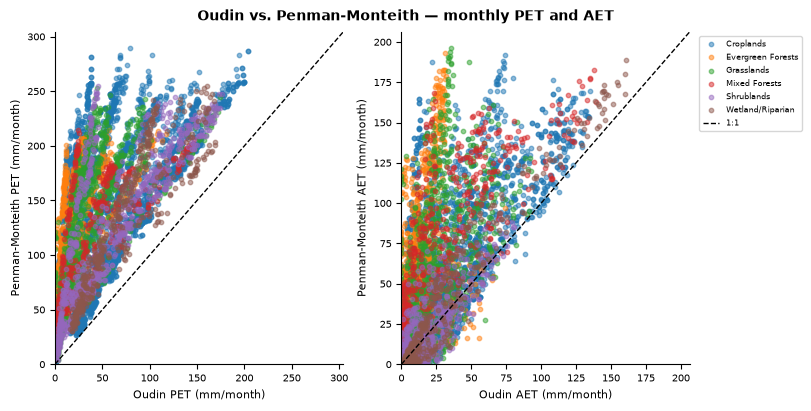

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

ecosystems = sorted(pet_aet_compare["ecosystem"].dropna().unique())
colors = dict(zip(ecosystems, plt.cm.tab10.colors[:len(ecosystems)]))

for ax, (obs_col, pred_col, label) in zip(
    axes,
    [("PET_oudin", "PET_pm", "PET (mm/month)"), ("AET_oudin", "AET_pm", "AET (mm/month)")],
):
    for eco in ecosystems:
        sub = pet_aet_compare[pet_aet_compare["ecosystem"] == eco]
        ax.scatter(sub[obs_col], sub[pred_col], s=10, alpha=0.5,
                   color=colors[eco], label=eco)

    lims = [0, pet_aet_compare[[obs_col, pred_col]].max().max() * 1.05]
    ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"Oudin {label}", fontsize=8)
    ax.set_ylabel(f"Penman-Monteith {label}", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

axes[1].legend(fontsize=6, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Oudin vs. Penman-Monteith — monthly PET and AET", fontsize=10, fontweight="bold")

plt.savefig("../Data/pet_comparison/pet_aet_oudin_vs_pm_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


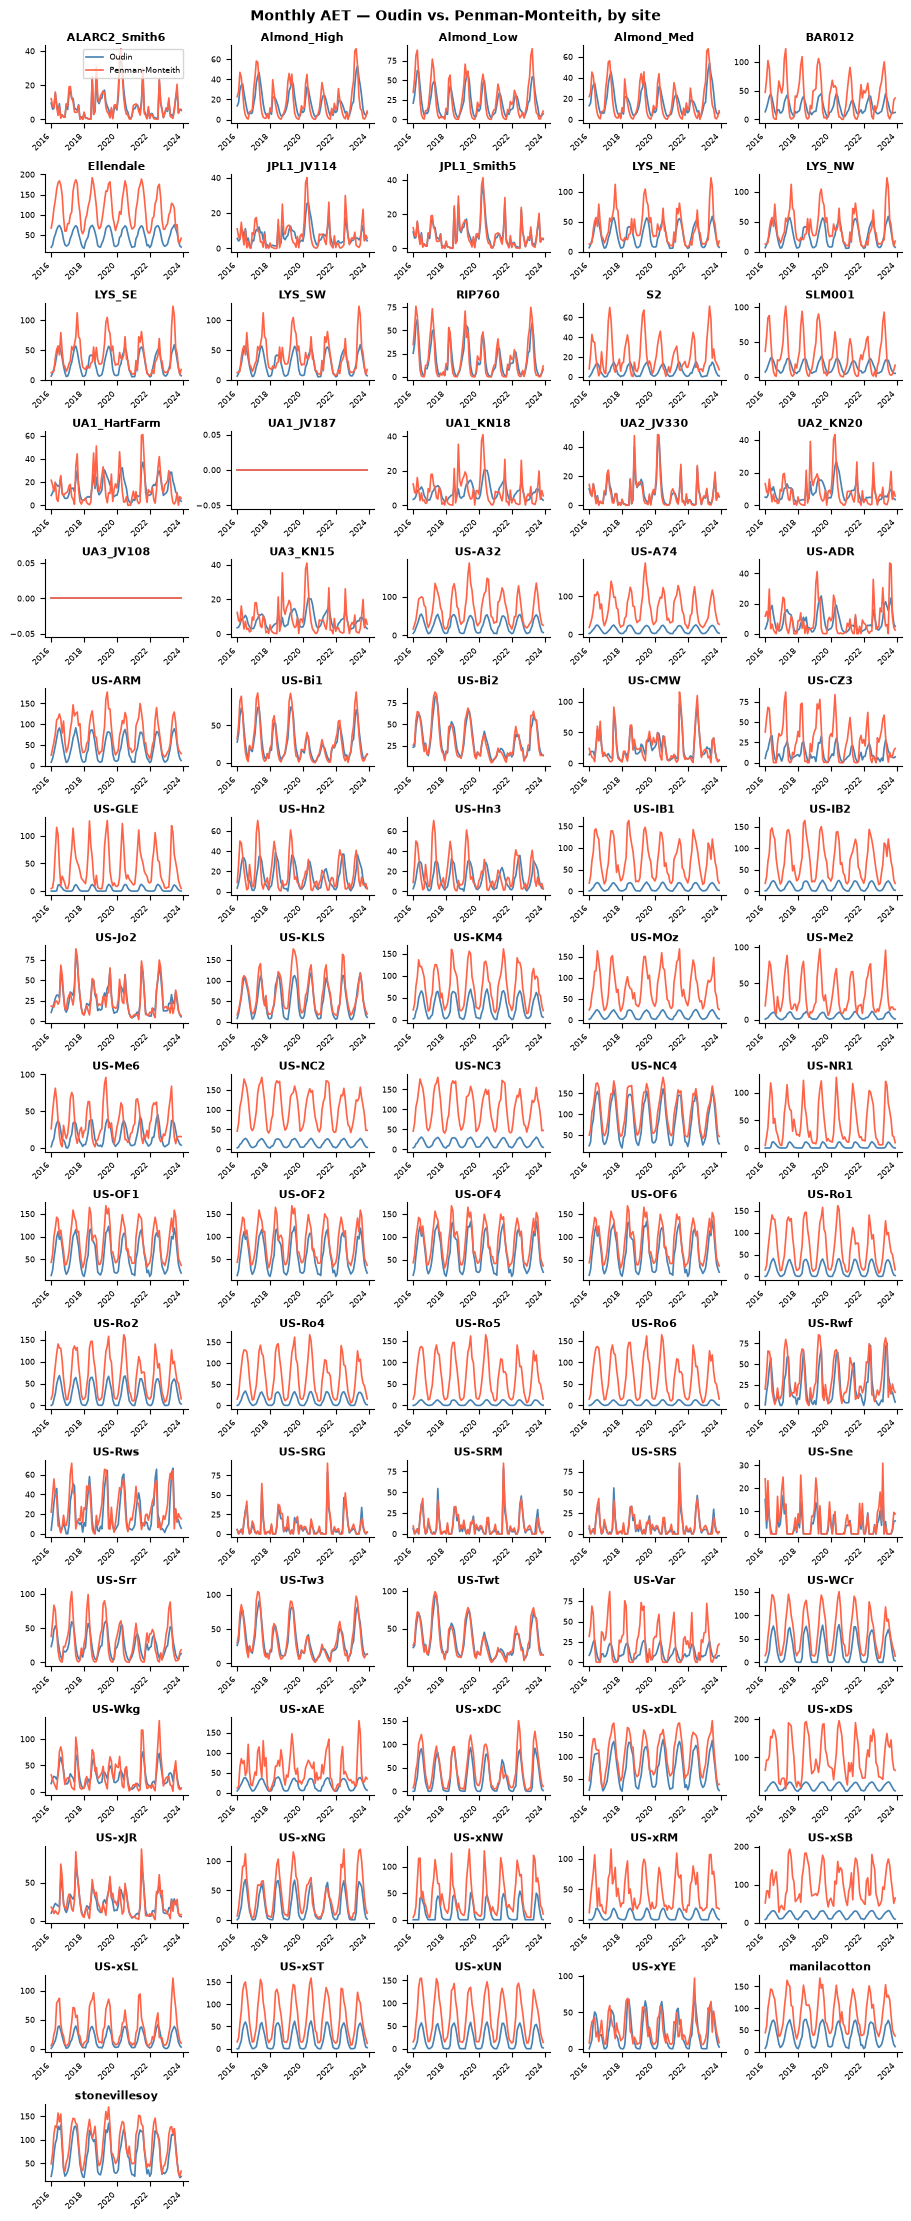

In [14]:
sites_list = sorted(pet_aet_compare["site"].unique())
n_cols = 5
n_rows = int(np.ceil(len(sites_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 1.3),
                          sharey=False, constrained_layout=True)
axes_flat = axes.flatten()

for ax, site in zip(axes_flat, sites_list):
    sub = pet_aet_compare[pet_aet_compare["site"] == site].sort_values("date_monthly")
    ax.plot(sub["date_monthly"], sub["AET_oudin"], color="steelblue", linewidth=1.2, label="Oudin")
    ax.plot(sub["date_monthly"], sub["AET_pm"], color="tomato", linewidth=1.2, label="Penman-Monteith")
    ax.set_title(site, fontsize=8, fontweight="bold", pad=3)
    ax.tick_params(axis="both", labelsize=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

for ax in axes_flat[len(sites_list):]:
    ax.set_visible(False)

axes_flat[0].legend(fontsize=6, loc="upper right")
fig.suptitle("Monthly AET — Oudin vs. Penman-Monteith, by site", fontsize=10, fontweight="bold")

plt.savefig("../Data/pet_comparison/aet_oudin_vs_pm_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()


Mean bias/RMSE by ecosystem (PM minus Oudin, mm/month):
                   PET_bias_mm  PET_rmse_mm  AET_bias_mm  AET_rmse_mm
ecosystem                                                            
Croplands                75.70        84.13        18.24        25.44
Evergreen Forests        87.07        97.65        44.33        53.95
Grasslands               82.94        92.86        30.96        40.30
Mixed Forests            65.96        74.32        46.02        52.23
Shrublands               64.52        71.19         2.59         9.93
Wetland/Riparian         57.92        63.36         7.33        12.86


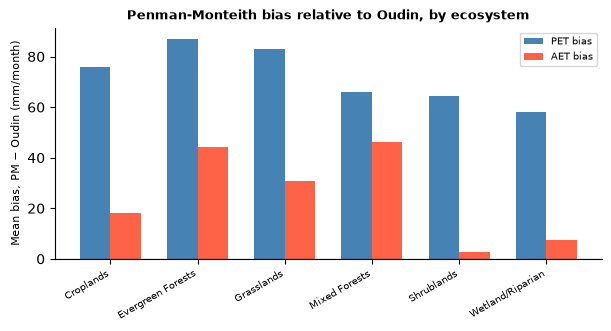

In [15]:
eco_summary = (
    site_metrics
    .groupby("ecosystem")[["PET_bias_mm", "PET_rmse_mm", "AET_bias_mm", "AET_rmse_mm"]]
    .mean()
    .round(2)
)
print("Mean bias/RMSE by ecosystem (PM minus Oudin, mm/month):")
print(eco_summary.to_string())

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
x = np.arange(len(eco_summary))
width = 0.35
ax.bar(x - width/2, eco_summary["PET_bias_mm"], width, label="PET bias", color="steelblue")
ax.bar(x + width/2, eco_summary["AET_bias_mm"], width, label="AET bias", color="tomato")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(eco_summary.index, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Mean bias, PM \u2212 Oudin (mm/month)", fontsize=8)
ax.legend(fontsize=7)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Penman-Monteith bias relative to Oudin, by ecosystem", fontsize=9, fontweight="bold")

plt.savefig("../Data/pet_comparison/bias_by_ecosystem.png", dpi=300, bbox_inches="tight")
plt.show()


### Summary & suggested follow-ups

This notebook gives an uncalibrated, apples-to-apples comparison of two PET methods driving the same WBM. Natural next steps, if useful:

- **Ecosystem-specific `Kc`** instead of the `KC_ETO_TO_PET = 1.0` baseline (e.g. FAO-56 generic land-cover coefficients, keyed off the `ecosystem` column already in `flux_towers`).
- **Add gridMET relative humidity** (`rmax`/`rmin` bands) the same way wind was added here, so Penman-Monteith uses real vapor pressure instead of the `e_a = e_tmin` fallback.
- **Calibrate the Penman-Monteith run** against OpenET/flux towers the way notebook 04 calibrated Oudin (same PET-multiplier optimization approach, just pointed at `wbm_results_pm` instead of the Oudin run) \u2014 right now this notebook only compares the two WBM configurations to each other, not to independent ET observations.